# Deep Learning Assignment 1
Submitters:
1. Amit Ner-Gaon 211649801
2. Chen Frydman 208009845

The purpose of this assignment is to build a simple neural network “from scratch” and to obtain a deep understanding of the forward/backward propagation process.

# Imports and Constants

In [292]:
import numpy as np

SEED = 42

# Section 1 - Forward Propagation

In [293]:
def initialize_parameters(layer_dims: list) -> dict:
    """
    Args:
        layer_dims (list): An array of the dimensions of each layer in the network (layer 0 is the size of the flattened input, layer L is the output softmax).
    Returns:
        parameters (dict): a dictionary containing the initialized W and b parameters of each layer {layer_number : {W,b}}.
    """
    rng = np.random.RandomState(SEED)  # for reproducibility

    parameters = {}  # {layer_number : {W,b}}

    L = (
        len(layer_dims) - 1
    )  # number of layers in the network (excluding the input layer)

    for l in range(
        1, L + 1
    ):  # starting from 1 because layer 0 is the input layer, which doesn't have parameters
        n_curr = layer_dims[l]
        n_prev = layer_dims[l - 1]

        current_weights = rng.normal(loc=0.0, scale=0.1, size=(n_curr, n_prev))

        parameters[l] = {
            "W": current_weights,
            "b": np.zeros((n_curr, 1)),  # bias is a vector of size n_curr
        }

    return parameters

In [294]:
def linear_forward(
    A: np.ndarray, W: np.ndarray, b: np.ndarray
) -> tuple[np.ndarray, dict]:
    """
    Args:
        A (np.ndarray): activations from previous layer (or input data): (size of previous layer, number of examples)
        W (np.ndarray): weights matrix, numpy array of shape (size of current layer, size of previous layer)
        b (np.ndarray): bias vector, numpy array of shape (size of the current layer, 1)
    Returns:
        Z (np.ndarray): the input of the activation function, also called pre-activation parameter
        linear_cache (dict): a python dictionary containing "A", "W" and "b" ; stored for computing the backward pass efficiently
    """
    Z = np.dot(W, A) + b  # Z = WA + b
    linear_cache: dict = {"A": A, "W": W, "b": b}
    return Z, linear_cache

$$Softmax(z)_i = \frac{\exp(z_i)}{\sum_j \exp(z_j)}$$

In [295]:
def softmax(Z: np.ndarray) -> tuple[np.ndarray, dict]:
    """
    Args:
        Z (np.ndarray): The linear component of the activation function, of shape (number of classes, number of examples)
    Returns:
        A (np.ndarray): The output of the softmax activation function, of shape (number of classes, number of examples)
        activation_cache (dict): stores "Z" (pre-activation) and "AL" (the softmax output),
            used by softmax_backward for the AL - Y shortcut without recomputing softmax.
    """
    shifted_Z = Z - np.max(
        Z, axis=0, keepdims=True
    )  # we substract maximum Z in order to avoid inf
    exp_Z = np.exp(shifted_Z)
    A = exp_Z / np.sum(
        exp_Z, axis=0, keepdims=True
    )  # axis=0 for sum down, keepdims for keeping the shape
    activation_cache: dict = {"Z": Z, "AL": A}
    return A, activation_cache

$$g(z)=max(0,z)$$
$$g'(z) = \begin{cases} 1 & \textit{if } z > 0 \\ 0 & \textit{if } z < 0 \end{cases}$$

In [296]:
def relu(Z: np.ndarray) -> tuple[np.ndarray, dict]:
    """
    Args:
        Z (np.ndarray): the linear component of the activation function
    Returns:
        A (np.ndarray): the activations of the layer
        activiation_cache (dict): dict with Z
    """
    A = np.maximum(0, Z)
    activation_cache = {"Z": Z}
    return A, activation_cache

In [297]:
def linear_activation_forward(
    A_prev: np.ndarray, W: np.ndarray, B: np.ndarray, activation: str
) -> tuple[np.ndarray, dict]:
    """
    Implement the forward propagation for the LINEAR->ACTIVATION layer
    Args:
        A_prev (np.ndarray): activations of the previous layer
        W (np.ndarray): the weights matrix of the current layer
        B (np.ndarray): the bias vector of the current layer
        activation (str): the activation function to be used (a string, either "softmax", or "relu")
    Returns:
        A (np.ndarray):  the activations of the current layer
        cache (dict): a joint dictionary containing both linear_cache and activation_cache
    """
    Z, linear_cache = linear_forward(A_prev, W, B)
    if activation.lower() == "relu":
        A, activation_cache = relu(Z)
    elif activation.lower() == "softmax":
        A, activation_cache = softmax(Z)
    else:
        raise ValueError("Unsupported activation function. Use 'softmax', or 'relu'.")
    cache: dict = {"linear_cache": linear_cache, "activation_cache": activation_cache}
    return A, cache

In [298]:
def apply_batchnorm(A: np.ndarray) -> np.ndarray:
    """
    performs batchnorm on the received activation values of a given layer.
    Args:
        A (np.ndarray): the activations of a given layer, of shape (size of the layer, number of examples)
    Returns:
        NA (np.ndarray):  the normalized activation values, based on the formula learned in class
    """
    # axis = 1 for row-wise calculation, meaning for each feature across all the examples
    mu = np.mean(A, axis=1, keepdims=True)
    var = np.var(A, axis=1, keepdims=True)

    NA = (A - mu) / np.sqrt(var + 1e-5)

    return NA

In [299]:
def l_model_forward(
    X: np.ndarray, parameters: dict, use_batchnorm: bool
) -> tuple[np.ndarray, list]:
    """
    Implement forward propagation for the [LINEAR->RELU]*(L-1)->LINEAR->SOFTMAX computation
    Args:
        X (np.ndarray): data, numpy array of shape (input size, number of examples)
        parameters (dict): the initialized W and b parameters of each layer
        use_batchnorm (bool): whether to use batch normalization or not
    Returns:
        AL (np.ndarray): last post-activation value
        caches (list): a list of all the cache objects generated by the linear_forward function
    """
    caches = []
    A = X
    L = len(parameters)  # number of layers in the neural network

    for l in range(1, L):  # loop from 1 to L-1
        A_prev = A
        W = parameters[l]["W"]
        b = parameters[l]["b"]
        A, cache = linear_activation_forward(A_prev, W, b, activation="relu")
        if use_batchnorm:
            A = apply_batchnorm(A)
        caches.append(cache)

    # Final layer with softmax activation
    W = parameters[L]["W"]
    b = parameters[L]["b"]
    AL, cache = linear_activation_forward(A, W, b, activation="softmax")
    caches.append(cache)

    return AL, caches

$$cost = -\frac{1}{m}\sum_{m=1}^{M}\sum_{c=1}^{C}y_i\log(\hat{y})$$

In [300]:
def compute_cost(AL: np.ndarray, Y: np.ndarray, parameters: dict = None, lambda_reg: float = 0.0):
    """
    Args:
        AL (np.ndarray): probability vector corresponding to the label predictions, shape (number of classes, number of examples)
        Y (np.ndarray): the labels vector (i.e. the ground truth), shape (number of classes, number of examples)
        parameters (dict): network parameters, required when lambda_reg > 0 for L2 penalty.
        lambda_reg (float): L2 regularization coefficient. 0 means no regularization.
    Returns:
        cost (float): the cross-entropy cost, optionally with L2 penalty
    """
    m = Y.shape[1]  # number of examples
    cost: float = -np.sum(Y * np.log(AL + 1e-7)) / m  # adding epsilon to avoid log(0)

    if lambda_reg > 0 and parameters is not None:
        l2_penalty = sum(np.sum(parameters[l]["W"] ** 2) for l in parameters)
        cost += (lambda_reg / (2 * m)) * l2_penalty

    return cost

# Section 2 - Backward Propagation

In [301]:
def linear_backward(
    dZ: np.ndarray, cache: tuple[np.ndarray, np.ndarray, np.ndarray]
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Backward propagation process for a single layer.
    Args:
        dZ: the gradient of the cost with respect to the linear output of the **current** layer (layer l).
        cache: tuple of values (A_prev, W, b).
    Returns:
        (dA_prev, dW, db)
            dA_prev: Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev.
            dW: Gradient of the cost with respect to W (current layer l), same shape as W.
            db: Gradient of the cost with respect to b (current layer l), same shape as b.
    """

    A_prev, W, b = cache

    m = A_prev.shape[1]  # batch size. Used for averaging the gradients over the batch.

    # dz ((n{l}, m), a_prev (n{l-1}, m), w (n_l, n{l-1}), b (n_l, 1))
    dW = (1 / m) * np.dot(dZ, A_prev.T)
    db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)

    return dA_prev, dW, db

In [302]:
def relu_backward(dA: np.ndarray, activation_cache: dict) -> np.ndarray:
    """
    Backward propagation for a ReLU unit.
    Args:
        dA (np.ndarray): post activation gradient
        activation_cache (dict): contains Z
    Returns:
        dZ (np.ndarray): gradient of the cost with respect to Z
    """
    Z = activation_cache["Z"] if isinstance(activation_cache, dict) else activation_cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

In [303]:
def softmax_backward(dA: np.ndarray, activation_cache: dict) -> np.ndarray:
    """
    Backward propagation for a softmax unit combined with cross-entropy loss.
    Uses the fused derivative shortcut: dZ = AL - Y.
    Args:
        dA (np.ndarray): carries the ground-truth labels Y here (not a traditional
            post-activation gradient). The softmax+cross-entropy shortcut skips the
            standard chain-rule step, so Y is passed through this slot instead.
        activation_cache (dict): contains "AL" (softmax output saved during forward pass).
    Returns:
        dZ (np.ndarray): gradient of the cost with respect to Z, equal to AL - Y.
    """
    AL = activation_cache["AL"]
    dZ = AL - dA  # dA is Y
    return dZ

In [304]:
def linear_activation_backward(dA: np.ndarray, cache: dict, activation: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    The backward propagation for the LINEAR->ACTIVATION layer. The function
    first computes dZ and then applies the linear_backward function.
    Args:
        dA (np.ndarray): post activation gradient of the current layer
        cache (dict): contains both the linear cache and the activations cache.
    Returns:
        (dA_prev, dW, db):
            dA_prev (np.ndarray): Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev.
            dW (np.ndarray): Gradient of the cost with respect to W (current layer l), same shape as W.
            db (np.ndarray): Gradient of the cost with respect to b (current layer l), same shape as b.
    """
    linear_cache = cache["linear_cache"]
    activation_cache = cache["activation_cache"]

    if activation.lower() == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation.lower() == "softmax":
        dZ = softmax_backward(dA, activation_cache)  
    else:
        raise ValueError("Unsupported activation function. Use 'relu' or 'softmax'.")

    dA_prev, dW, db = linear_backward(
        dZ, (linear_cache["A"], linear_cache["W"], linear_cache["b"])
    )
    return dA_prev, dW, db

In [305]:
def l_model_backward(AL: np.ndarray, Y: np.ndarray, caches: list) -> dict:
    """
    Backward propagation process for the entire network.
    The backpropagation for the softmax function is done only once (as only the output layers uses it).
    The backpropagation for the RELU is done iteratively over all the remaining layers of the network.
    Args:
        AL (np.ndarray): probability vector, output of the forward propagation (l_model_forward())
        Y (np.ndarray): true "label" vector (ground truth)
        caches (list): list of caches containing for each layer: a) the linear cache; b) the activation cache.

    Returns:
        grads: A dictionary with the gradients
                 grads["dA" + str(l)] = ...
                 grads["dW" + str(l)] = ...
                 grads["db" + str(l)] = ...
    """
    grads = {}
    L = len(caches)
    # Y = Y.reshape(AL.shape) # 

    # Output layer: pass Y as dA; softmax_backward applies the AL - Y shortcut internally.
    current_cache = caches[L - 1]
    dA_prev, dW, db = linear_activation_backward(Y, current_cache, activation="softmax")
    grads["dA" + str(L - 1)] = dA_prev
    grads["dW" + str(L)] = dW
    grads["db" + str(L)] = db

    # Hidden layers (L-1 to 1) with ReLU.
    for l in reversed(range(L - 1)): # loop from L-2 to 0. index l much layer l + 1.
        current_cache = caches[l]
        dA_prev, dW, db = linear_activation_backward(
            grads["dA" + str(l + 1)], current_cache, activation="relu"
        )
        grads["dA" + str(l)] = dA_prev
        grads["dW" + str(l + 1)] = dW
        grads["db" + str(l + 1)] = db

    return grads

In [306]:
def update_parameters(parameters: dict[np.ndarray], grads: dict[np.ndarray], learning_rate: float, lambda_reg: float = 0.0, m: int = 1) -> dict[np.ndarray]:
    """
    Update parameters using gradient descent
    Args:
        parameters (dict[np.ndarray]): a python dictionary containing the DNN architecture's parameters.
        grads (dict[np.ndarray]): a python dictionary containing the gradients (generated by L_model_backward)
        learning_rate (float): the learning rate (alpha).
        lambda_reg (float): L2 regularization coefficient. Adds (lambda_reg/m)*W to each weight gradient (weight decay).
        m (int): number of training examples in the current batch, used to scale the L2 penalty.
    Returns:
        parameters (dict[np.ndarray]): python dictionary containing your updated parameters
    """
    L = len(parameters)

    for l in range(1, L + 1):
        parameters[l]["W"] = parameters[l]["W"] - learning_rate * (grads["dW" + str(l)] + (lambda_reg / m) * parameters[l]["W"])
        parameters[l]["b"] = parameters[l]["b"] - learning_rate * grads["db" + str(l)]

    return parameters

# Section 3 - Full Training Loop

In [307]:
def l_layer_model(
    X: np.ndarray,
    Y: np.ndarray,
    layers_dims: list[int],
    learning_rate: float,
    num_iterations: int,
    batch_size: int,
    use_batchnorm: bool = False,
    X_val: np.ndarray = None,
    Y_val: np.ndarray = None,
    patience: int = 1,
    lambda_reg: float = 0.0,
) -> tuple[dict, list[float], list[float]]:
    """Implements an L-layer neural network.
    All layers but the last have the ReLU activation; the last layer applies softmax.
    Training follows: initialize -> L_model_forward -> compute_cost -> L_model_backward -> update_parameters.

    A "training iteration" (or "step") is one gradient update on one mini-batch. An
    "epoch" is one full pass over the training set. The cost is recorded every 100
    iterations, matching the assignment spec.

    Args:
        X (np.ndarray): training data, shape (features, num_examples).
        Y (np.ndarray): one-hot labels, shape (n_classes, num_examples).
        layers_dims (list[int]): layer sizes including the input layer.
        learning_rate (float): alpha.
        num_iterations (int): maximum number of gradient steps (iterations).
        batch_size (int): number of examples per mini-batch.
        use_batchnorm (bool): apply batchnorm after each ReLU.
        X_val (np.ndarray): optional validation data, shape (features, num_val_examples).
        Y_val (np.ndarray): optional validation labels, shape (n_classes, num_val_examples).
        patience (int): stop after this many 100-iteration checks with no validation improvement.
        lambda_reg (float): L2 regularization coefficient. 0 disables L2.

    Returns:
        parameters (dict): learned parameters (best-validation snapshot when early stopping is active).
        costs (list[float]): train cost recorded every 100 iterations.
        val_costs (list[float]): validation cost recorded every 100 iterations (empty if no val data).
    """
    rng = np.random.RandomState(SEED)
    parameters = initialize_parameters(layers_dims)
    costs: list[float] = []
    val_costs: list[float] = []

    use_early_stopping = (X_val is not None) and (Y_val is not None)
    best_val_cost = np.inf
    no_improve_count = 0
    best_parameters = None
    should_stop = False

    num_examples = X.shape[1]
    step = 0
    epoch = 0

    while step < num_iterations and not should_stop:
        epoch += 1
        permutation = rng.permutation(num_examples)
        X_shuffled = X[:, permutation]
        Y_shuffled = Y[:, permutation]

        for start in range(0, num_examples, batch_size):
            if step >= num_iterations or should_stop:
                break

            end = min(start + batch_size, num_examples)
            X_batch = X_shuffled[:, start:end]
            Y_batch = Y_shuffled[:, start:end]
            m_batch = X_batch.shape[1]

            AL, caches = l_model_forward(X_batch, parameters, use_batchnorm)
            grads = l_model_backward(AL, Y_batch, caches)
            parameters = update_parameters(parameters, grads, learning_rate, lambda_reg, m_batch)
            step += 1

            # Every 100 iterations: record costs and check early stopping.
            if step % 100 == 0:
                AL_full, _ = l_model_forward(X, parameters, use_batchnorm)
                train_cost = compute_cost(AL_full, Y, parameters, lambda_reg)
                costs.append(train_cost)
                print(f"Step {step} (epoch {epoch}): train cost = {train_cost:.4f}", end="")

                if use_early_stopping:
                    AL_val, _ = l_model_forward(X_val, parameters, use_batchnorm)
                    val_cost = compute_cost(AL_val, Y_val, parameters, lambda_reg)
                    val_costs.append(val_cost)
                    print(f" | val cost = {val_cost:.4f}", end="")

                    if val_cost < best_val_cost - 1e-4:
                        best_val_cost = val_cost
                        best_parameters = {
                            l: {k: v.copy() for k, v in params.items()}
                            for l, params in parameters.items()
                        }
                        no_improve_count = 0
                    else:
                        no_improve_count += 1
                        if no_improve_count >= patience:
                            should_stop = True
                print()

    print(f"\nTraining finished: {step} iterations, {epoch} epochs.")
    if should_stop:
        print(f"Early stopping triggered (no val improvement for {patience * 100} iterations).")

    final_parameters = best_parameters if best_parameters is not None else parameters
    return final_parameters, costs, val_costs

In [308]:
def predict(X: np.ndarray, Y: np.ndarray, parameters: dict, use_batchnorm: bool = False) -> float:
    """
    The function receives an input data and the true labels and calculates the accuracy of
    the trained neural network on the data.

    Args:
        X (np.ndarray): the input data, a numpy array of shape (height*width, number_of_examples)
        Y (np.ndarray): One-hot vector, the "real" labels of the data, a vector of shape (num_of_classes, number of examples)
        parameters (dict): (layer_number : {W,b}) python dictionary containing the DNN architectures parameters.
        use_batchnorm (bool): whether to apply batch normalization during forward pass (must match training setting).

    Returns:
        accuracy (float): the percentage of the samples for which the correct label receives the highest confidence score. 
    """
    AL, _ = l_model_forward(X, parameters, use_batchnorm)
    predictions = np.argmax(AL, axis=0)   # shape: (num_examples,)
    true_labels = np.argmax(Y, axis=0)    # shape: (num_examples,)
    accuracy = float(np.mean(predictions == true_labels))
    return accuracy

# Section 4 - Experiments

## Section 4.a - Data Preparation

The MNIST dataset is publicly available at http://yann.lecun.com/exdb/mnist/ and consists of the following four parts:

- Training set images: train-images-idx3-ubyte.gz (9.9 MB, 47 MB unzipped, 60,000 examples)
- Training set labels: train-labels-idx1-ubyte.gz (29 KB, 60 KB unzipped, 60,000 labels)
- Test set images: t10k-images-idx3-ubyte.gz (1.6 MB, 7.8 MB, 10,000 examples)
- Test set labels: t10k-labels-idx1-ubyte.gz (5 KB, 10 KB unzipped, 10,000 labels)

In [309]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

Download the MNIST dataset

In [310]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True) #  returns (data, target). Data: Rows = samples, Columns = features.
print(f"X type: {type(X)}")
print(f"y type: {type(y)}")
X = X.values
y = y.astype(int).values

print("MNIST dataset loaded.")
print(f"X type: {type(X)}")
print(f"X shape: {X.shape}")
print(f"y type: {type(y)}")
print(f"y shape: {y.shape}")

X type: <class 'pandas.DataFrame'>
y type: <class 'pandas.Series'>
MNIST dataset loaded.
X type: <class 'numpy.ndarray'>
X shape: (70000, 784)
y type: <class 'numpy.ndarray'>
y shape: (70000,)


Normalize to [-1, 1] range:


In [311]:
X = ((X / 255.) - .5) * 2

Split into training, validation, and test set:

In [312]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.2, shuffle=True, stratify=y_temp)

Flatten input

In [313]:
X_train = X_train.reshape(X_train.shape[0], 784)
X_valid = X_valid.reshape(X_valid.shape[0], 784)
X_test = X_test.reshape(X_test.shape[0], 784)

One Hot Encoding

In [314]:
lb = LabelBinarizer()

lb.fit(y)  # Fit the label binarizer on all the labels to learn the classes.

y_train_oh = lb.transform(y_train)
y_valid_oh = lb.transform(y_valid)
y_test_oh  = lb.transform(y_test)

## Section 4.b - Training Configuration (Documentation)

Network parameters

In [315]:
layer_dims = [784, 20, 7, 5, 10] # including the input layer
use_batchnorm = False
learning_rate = 0.009
batch_size = 64
num_iterations = 30000   # max gradient steps (iterations); early stopping will kick in earlier
patience = 100  # stop after 1 check interval (100 steps) with no val improvement

Train the network

In [316]:
# Transpose to (features, examples) as expected by the network
X_train_T = X_train.T   # (784, m_train)
X_valid_T = X_valid.T   # (784, m_valid)
X_test_T  = X_test.T    # (784, m_test)

Y_train_T = y_train_oh.T  # (10, m_train)
Y_valid_T = y_valid_oh.T  # (10, m_valid)
Y_test_T  = y_test_oh.T   # (10, m_test)


parameters, costs, val_costs = l_layer_model(
    X_train_T, Y_train_T,
    layer_dims,
    learning_rate,
    num_iterations,
    batch_size,
    use_batchnorm,
    X_val=X_valid_T,
    Y_val=Y_valid_T,
    patience=patience,
)

# Final accuracy on all three splits
train_acc = predict(X_train_T, Y_train_T, parameters)
val_acc   = predict(X_valid_T, Y_valid_T, parameters)
test_acc  = predict(X_test_T,  Y_test_T,  parameters)

print(f"\nFinal Accuracy:")
print(f"  Train : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Val   : {val_acc:.4f}   ({val_acc*100:.2f}%)")
print(f"  Test  : {test_acc:.4f}  ({test_acc*100:.2f}%)")

Step 100 (epoch 1): train cost = 2.3002 | val cost = 2.3003
Step 200 (epoch 1): train cost = 2.2967 | val cost = 2.2968
Step 300 (epoch 1): train cost = 2.2914 | val cost = 2.2916
Step 400 (epoch 1): train cost = 2.2829 | val cost = 2.2831
Step 500 (epoch 1): train cost = 2.2683 | val cost = 2.2685
Step 600 (epoch 1): train cost = 2.2404 | val cost = 2.2408
Step 700 (epoch 1): train cost = 2.1880 | val cost = 2.1884
Step 800 (epoch 2): train cost = 2.0997 | val cost = 2.1007
Step 900 (epoch 2): train cost = 2.0084 | val cost = 2.0107
Step 1000 (epoch 2): train cost = 1.9289 | val cost = 1.9315
Step 1100 (epoch 2): train cost = 1.8511 | val cost = 1.8536
Step 1200 (epoch 2): train cost = 1.7813 | val cost = 1.7846
Step 1300 (epoch 2): train cost = 1.7057 | val cost = 1.7087
Step 1400 (epoch 2): train cost = 1.6228 | val cost = 1.6270
Step 1500 (epoch 3): train cost = 1.4836 | val cost = 1.4905
Step 1600 (epoch 3): train cost = 1.3704 | val cost = 1.3775
Step 1700 (epoch 3): train cost =

## Section 4.c - Required Report Outputs

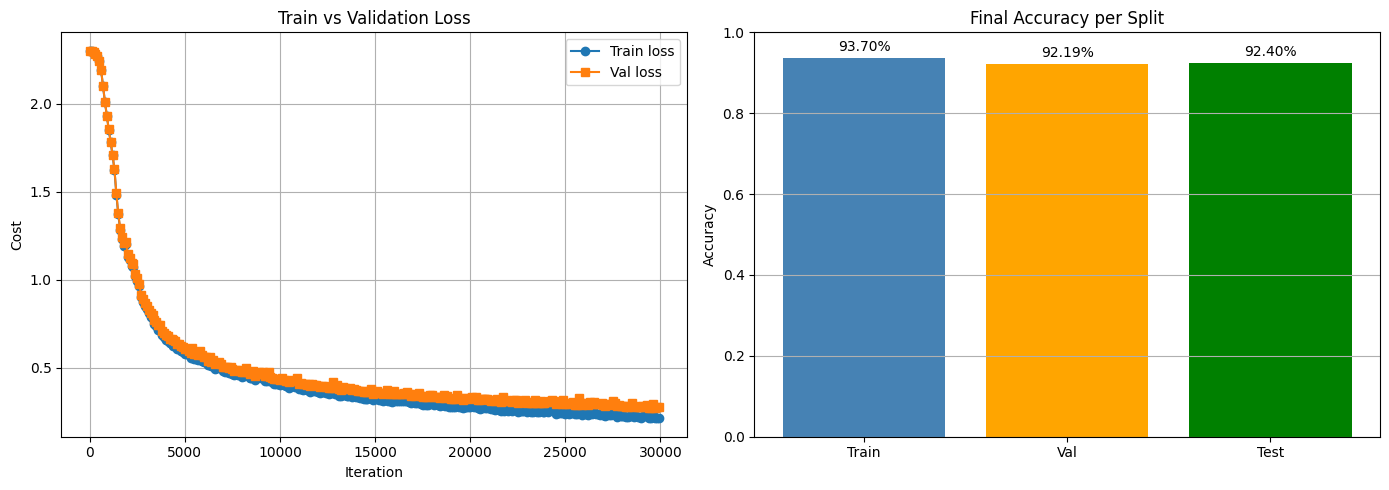

In [317]:
import matplotlib.pyplot as plt

iterations = list(range(0, len(costs) * 100, 100))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curve ---
axes[0].plot(iterations, costs, marker='o', label='Train loss')
axes[0].plot(iterations, val_costs, marker='s', label='Val loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy bar chart ---
labels = ['Train', 'Val', 'Test']
accuracies = [train_acc, val_acc, test_acc]
bars = axes[1].bar(labels, accuracies, color=['steelblue', 'orange', 'green'])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Final Accuracy per Split')
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{acc*100:.2f}%', ha='center', va='bottom')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

## Section 5 - Experiment: Batchnorm ON

Repeat of Section 4 with `use_batchnorm=True`. All other hyperparameters are identical.

In [318]:
import time

start_time = time.time()

parameters_bn, costs_bn, val_costs_bn = l_layer_model(
    X_train_T, Y_train_T,
    layer_dims,
    learning_rate,
    num_iterations,
    batch_size,
    use_batchnorm=True,
    X_val=X_valid_T,
    Y_val=Y_valid_T,
    patience=patience,
)

elapsed_bn = time.time() - start_time
print(f"\nTraining time (batchnorm ON): {elapsed_bn:.2f}s")

train_acc_bn = predict(X_train_T, Y_train_T, parameters_bn, use_batchnorm=True)
val_acc_bn   = predict(X_valid_T, Y_valid_T, parameters_bn, use_batchnorm=True)
test_acc_bn  = predict(X_test_T,  Y_test_T,  parameters_bn, use_batchnorm=True)

print(f"\nFinal Accuracy (batchnorm ON):")
print(f"  Train : {train_acc_bn:.4f} ({train_acc_bn*100:.2f}%)")
print(f"  Val   : {val_acc_bn:.4f}   ({val_acc_bn*100:.2f}%)")
print(f"  Test  : {test_acc_bn:.4f}  ({test_acc_bn*100:.2f}%)")

Step 100 (epoch 1): train cost = 2.2651 | val cost = 2.2654
Step 200 (epoch 1): train cost = 2.2069 | val cost = 2.2074
Step 300 (epoch 1): train cost = 2.1406 | val cost = 2.1419
Step 400 (epoch 1): train cost = 2.0832 | val cost = 2.0852
Step 500 (epoch 1): train cost = 2.0380 | val cost = 2.0408
Step 600 (epoch 1): train cost = 2.0015 | val cost = 2.0051
Step 700 (epoch 1): train cost = 1.9676 | val cost = 1.9719
Step 800 (epoch 2): train cost = 1.9340 | val cost = 1.9390
Step 900 (epoch 2): train cost = 1.9007 | val cost = 1.9060
Step 1000 (epoch 2): train cost = 1.8661 | val cost = 1.8716
Step 1100 (epoch 2): train cost = 1.8299 | val cost = 1.8355
Step 1200 (epoch 2): train cost = 1.7945 | val cost = 1.8002
Step 1300 (epoch 2): train cost = 1.7581 | val cost = 1.7637
Step 1400 (epoch 2): train cost = 1.7264 | val cost = 1.7321
Step 1500 (epoch 3): train cost = 1.6980 | val cost = 1.7040
Step 1600 (epoch 3): train cost = 1.6717 | val cost = 1.6775
Step 1700 (epoch 3): train cost =

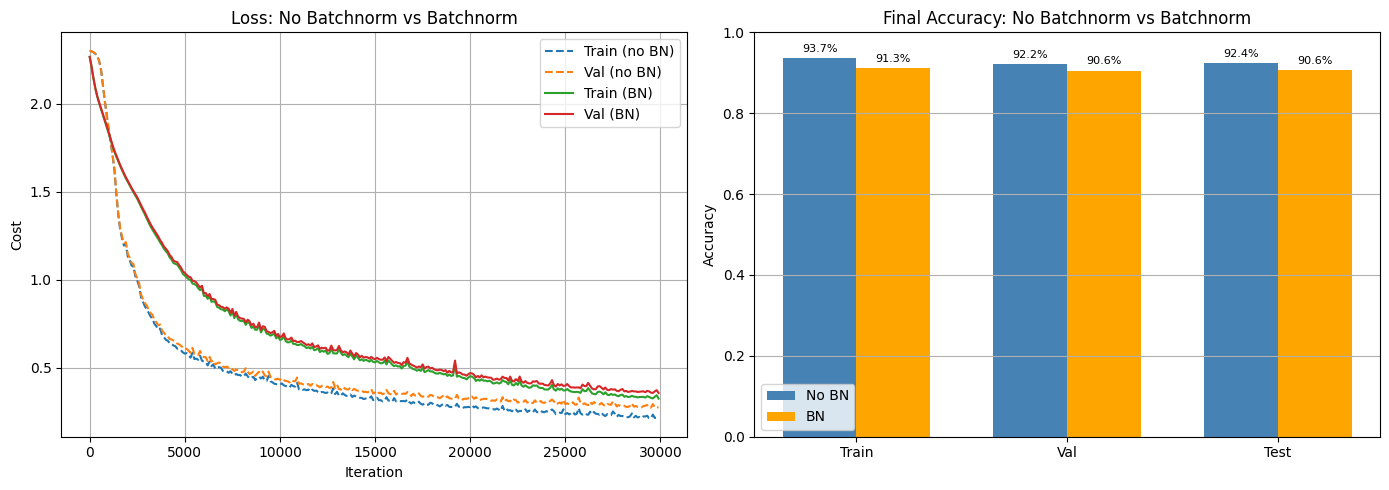

In [319]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves: no batchnorm vs batchnorm ---
iters_no_bn = list(range(0, len(costs) * 100, 100))
iters_bn    = list(range(0, len(costs_bn) * 100, 100))

axes[0].plot(iters_no_bn, costs,       label='Train (no BN)',  linestyle='--')
axes[0].plot(iters_no_bn, val_costs,   label='Val (no BN)',    linestyle='--')
axes[0].plot(iters_bn,    costs_bn,    label='Train (BN)')
axes[0].plot(iters_bn,    val_costs_bn,label='Val (BN)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')
axes[0].set_title('Loss: No Batchnorm vs Batchnorm')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy comparison bar chart ---
labels = ['Train', 'Val', 'Test']
x = np.arange(len(labels))
width = 0.35

bars1 = axes[1].bar(x - width/2, [train_acc, val_acc, test_acc],       width, label='No BN', color='steelblue')
bars2 = axes[1].bar(x + width/2, [train_acc_bn, val_acc_bn, test_acc_bn], width, label='BN',    color='orange')

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Final Accuracy: No Batchnorm vs Batchnorm')
axes[1].legend()
axes[1].grid(axis='y')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Section 6 - Experiment: L2 Regularization

**Changes made to support L2:**
- `compute_cost`: added `lambda_reg` and `parameters` arguments. When `lambda_reg > 0`, adds the penalty term `(λ/2m) * Σ||W^[l]||²` to the cross-entropy loss. This penalizes large weights during training.
- `update_parameters`: added `lambda_reg` and `m` arguments. Adds `(λ/m) * W` to each weight gradient before the update, equivalent to multiplying W by `(1 - α·λ/m)` each step — shrinking weights toward zero (weight decay).
- `l_layer_model`: added `lambda_reg` argument and passes it through to both functions above.

In [320]:
lambda_reg = 0.1

parameters_l2, costs_l2, val_costs_l2 = l_layer_model(
    X_train_T, Y_train_T,
    layer_dims,
    learning_rate,
    num_iterations,
    batch_size,
    use_batchnorm=False,
    X_val=X_valid_T,
    Y_val=Y_valid_T,
    patience=patience,
    lambda_reg=lambda_reg,
)

train_acc_l2 = predict(X_train_T, Y_train_T, parameters_l2)
val_acc_l2   = predict(X_valid_T, Y_valid_T, parameters_l2)
test_acc_l2  = predict(X_test_T,  Y_test_T,  parameters_l2)

print(f"\nFinal Accuracy (L2 λ={lambda_reg}):")
print(f"  Train : {train_acc_l2:.4f} ({train_acc_l2*100:.2f}%)")
print(f"  Val   : {val_acc_l2:.4f}   ({val_acc_l2*100:.2f}%)")
print(f"  Test  : {test_acc_l2:.4f}  ({test_acc_l2*100:.2f}%)")

Step 100 (epoch 1): train cost = 2.3004 | val cost = 2.3010
Step 200 (epoch 1): train cost = 2.2969 | val cost = 2.2976
Step 300 (epoch 1): train cost = 2.2918 | val cost = 2.2925
Step 400 (epoch 1): train cost = 2.2836 | val cost = 2.2843
Step 500 (epoch 1): train cost = 2.2697 | val cost = 2.2705
Step 600 (epoch 1): train cost = 2.2435 | val cost = 2.2444
Step 700 (epoch 1): train cost = 2.1944 | val cost = 2.1953
Step 800 (epoch 2): train cost = 2.1096 | val cost = 2.1110
Step 900 (epoch 2): train cost = 2.0171 | val cost = 2.0198
Step 1000 (epoch 2): train cost = 1.9378 | val cost = 1.9409
Step 1100 (epoch 2): train cost = 1.8599 | val cost = 1.8629
Step 1200 (epoch 2): train cost = 1.7906 | val cost = 1.7943
Step 1300 (epoch 2): train cost = 1.7189 | val cost = 1.7224
Step 1400 (epoch 2): train cost = 1.6453 | val cost = 1.6498
Step 1500 (epoch 3): train cost = 1.5165 | val cost = 1.5236
Step 1600 (epoch 3): train cost = 1.3956 | val cost = 1.4030
Step 1700 (epoch 3): train cost =

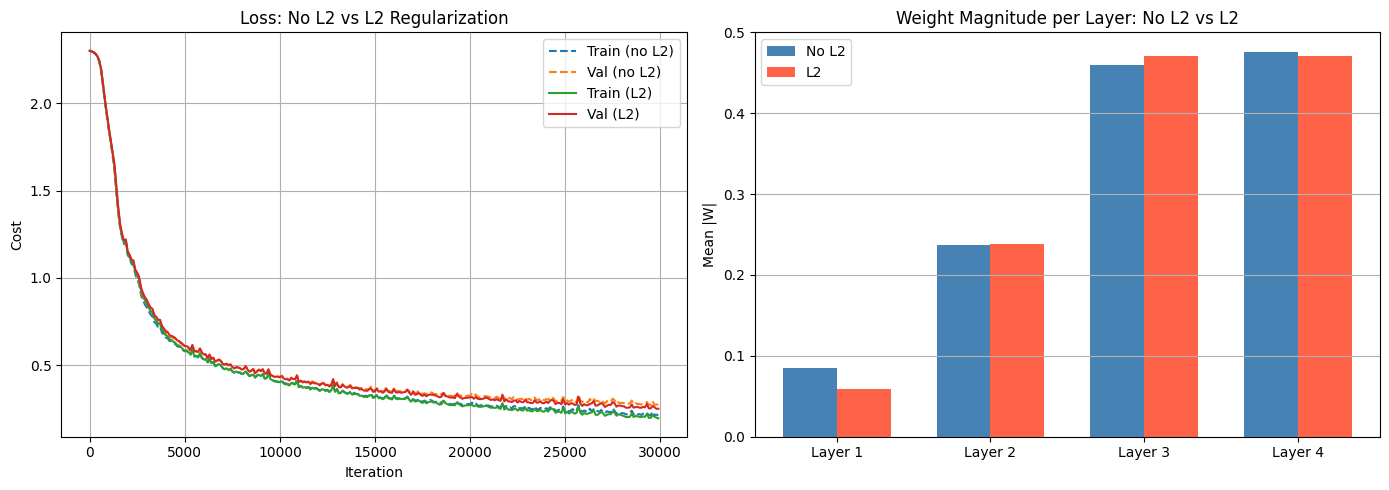

In [321]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss curves ---
iters_no_l2 = list(range(0, len(costs) * 100, 100))
iters_l2    = list(range(0, len(costs_l2) * 100, 100))

axes[0].plot(iters_no_l2, costs,        label='Train (no L2)', linestyle='--')
axes[0].plot(iters_no_l2, val_costs,    label='Val (no L2)',   linestyle='--')
axes[0].plot(iters_l2,    costs_l2,     label='Train (L2)')
axes[0].plot(iters_l2,    val_costs_l2, label='Val (L2)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')
axes[0].set_title('Loss: No L2 vs L2 Regularization')
axes[0].legend()
axes[0].grid(True)

# --- Weight magnitude comparison per layer ---
L = len(parameters)
layer_labels = [f'Layer {l}' for l in range(1, L + 1)]
w_norms_no_l2 = [np.mean(np.abs(parameters[l]['W']))    for l in range(1, L + 1)]
w_norms_l2    = [np.mean(np.abs(parameters_l2[l]['W'])) for l in range(1, L + 1)]

x = np.arange(L)
width = 0.35
bars1 = axes[1].bar(x - width/2, w_norms_no_l2, width, label='No L2', color='steelblue')
bars2 = axes[1].bar(x + width/2, w_norms_l2,    width, label='L2',    color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(layer_labels)
axes[1].set_ylabel('Mean |W|')
axes[1].set_title('Weight Magnitude per Layer: No L2 vs L2')
axes[1].legend()
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

# Section 5 - Conclusions